# LabCompass-RL: fine-tuning the design prior with Flow-GRPO

This notebook adapts `validation_pipeline.ipynb` from **training-free loss guidance** to
**reinforcement learning (Flow-GRPO)**.

**Pipeline recap**
1. A frozen **surrogate forward model** `Φ` maps a *design* (6-dim morphogen protocol) → cell states → **phenotype** (brain-Region distribution).
2. A **prior flow** generates plausible designs.
3. Instead of steering the frozen prior at sampling time (loss guidance), here we **fine-tune the prior** so that *sampling from it directly* produces designs whose predicted phenotype matches a target.

**Reward** = `-cross_entropy(predicted_region_dist, target_region_dist)` — exactly the negative of the notebook's `loss_fns`, packed together with the frozen `forward_model` into a single `RewardModel`.

Target phenotype: the Region distribution of `XAV_3+SHH_1` (same target used in the loss-guidance notebook).

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# --- make our local modules importable (order matters: our forward_model first) ---
sys.path.insert(0, "/ictstr01/groups/ml01/workspace/ken_wang/LabCompass-RL")

from sc_exp_design.constants import DataFields, PredictionFields
from sc_exp_design.models import FlowMatching
from forward_model import ForwardModel

# Flow-GRPO trainer + RL adapters (now packaged under sc_exp_design.rl)
from sc_exp_design.rl.flow_grpo_finetune import train_flow_grpo, FlowGRPOConfig, sample_trajectory
from sc_exp_design.rl.labcompass_rl_utils import (patch_pickled_lambdas, build_target_phenotype,
                                 RewardModel, FlowPolicy)

DEVICE = "cuda"
torch.manual_seed(0)

In [2]:
# checkpoints (same as validation_pipeline.ipynb)
PERTURBATION_RESPONSE_MODEL_PATH = "/lustre/groups/ml01/projects/inverse_perturbation_models/dumps/neurogenesis_morphogens/2025-10-01_14-55-19/decent-vortex-1_FlowMatching.pkl"
TARGET_PREDICTION_MODEL_PATH     = "/lustre/groups/ml01/projects/inverse_perturbation_models/dumps/neurogenesis_morphogens/target_prediction_2025-08-26_16-24-50/vital-fog-2_PerturbationApproximatePosterior.pkl"
PRIOR_FLOW_MODEL_PATH            = "/lustre/groups/ml01/projects/inverse_perturbation_models/dumps/neurogenesis_morphogens/2025-10-01_17-23-24/devout-frost-2_FlowMatching.pkl"

TARGET_COMB = "XAV_3+SHH_1"     # target design/phenotype to steer toward
molecules   = ("FGF8", "XAV", "RA", "CHIR", "SHH", "BMP4")

## 1. Load the frozen surrogate forward model Φ

In [3]:
# perturbation-response (surrogate) flow
flow_matching = FlowMatching.load(PERTURBATION_RESPONSE_MODEL_PATH)

# re-prepare train data with the Region target covariate (as in validation_pipeline)
data_config = {
    "sample_rep": flow_matching.data_manager.sample_rep,
    "control_key": flow_matching.data_manager.control_key,
    "perturbations": flow_matching.data_manager.perturbations,
    "perturbation_covariates": flow_matching.data_manager.perturbation_covariates,
    "perturbation_reps": flow_matching.data_manager.perturbation_reps,
    "load_target_covariates": True,
    "target_covariates": {"Region": "label"},
    "target_covariates_in_obsm": None,
    "target_covariates_kwargs": {"Region": {}},
}
flow_matching.prepare_train_data(flow_matching.train_data.adata, **data_config)

# wrap surrogate + target predictor into the ForwardModel
forward_model = ForwardModel(flow_matching)
forward_model.load_target_prediction_model(TARGET_PREDICTION_MODEL_PATH)

# NOTE: the checkpoints were pickled under a different Python; rebuild the
# cloudpickled-by-value ConditionEncoder pooling lambda to avoid a segfault.
print("patched surrogate lambdas:", patch_pickled_lambdas(flow_matching))

patched surrogate lambdas: 1


In [4]:
# data objects + label encoders
train_data      = flow_matching.train_data
validation_data = flow_matching.validation_data
if isinstance(validation_data, dict):
    validation_data = next(iter(validation_data.values()))
train_adata      = train_data.adata
validation_adata = validation_data.adata
perturbation_covariate_key = train_data.data.perturbation_covariates[0]

le_region  = LabelEncoder().fit(train_adata.obs["Region"])
ohe_region = OneHotEncoder(sparse_output=False).fit(train_adata.obs["Region"].values.reshape(-1, 1))
regions    = list(le_region.classes_)
print("state_dim:", validation_data.state_data.shape[1], "| n_regions:", len(regions))

state_dim: 20 | n_regions: 8


## 2. Load the design prior

In [5]:
prior_flow = FlowMatching.load(PRIOR_FLOW_MODEL_PATH)
print("patched prior lambdas:", patch_pickled_lambdas(prior_flow))
D = prior_flow.cvf_config.flow_dim          # design dimensionality (6 morphogens)
print("design dim D =", D)

patched prior lambdas: 0
design dim D = 6


## 3. Build the reward model and the policy

* **`RewardModel(designs) -> reward`**: ReLU(design) → frozen surrogate (fixed-noise cells) → Region logits → `-cross_entropy(target)`.
* **`FlowPolicy`**: adapts the prior's `velocity_field` to the `policy(x, t) -> velocity` contract of `flow_grpo_finetune`, sharing the same parameters so GRPO updates the prior **in place**.

In [6]:
# target phenotype == cond2target[TARGET_COMB] (empirical Region proportions of real cells)
target = build_target_phenotype(validation_adata, ohe_region, TARGET_COMB)   # [1, n_regions]
print(f"target Region distribution for {TARGET_COMB}:")
print(pd.Series(target.ravel(), index=regions).round(3).to_string())

# phenotype loss == validation_pipeline loss_fns
loss_fns = {
    "Region": lambda pred, tgt: -torch.sum(tgt * torch.nn.functional.log_softmax(pred, dim=-1), dim=-1)
}

reward_model = RewardModel(
    forward_model, loss_fns, {"Region": target},
    num_forward_pass_per_sample=64,     # cells simulated per design when scoring
    n_time_steps_forward_model=20,
    non_linearity=torch.nn.ReLU(),
).to(DEVICE)

policy = FlowPolicy(prior_flow).to(DEVICE)

target Region distribution for XAV_3+SHH_1:
DRG            0.008
ENS            0.000
Forebrain      0.415
Hindbrain      0.016
Midbrain       0.455
SYM            0.000
Spinal cord    0.057
TG             0.049


### Sanity check the flow-grpo convention

`flow_grpo` uses `t=1→noise, 0→data`; `sc_exp_design` uses the opposite. `FlowPolicy` maps
`v_grpo(x,t) = -v_sc(x, 1-t)`. With `noise_level=0` the GRPO rollout is a deterministic ODE and
must reproduce the prior's own samples.

In [7]:
cfg = FlowGRPOConfig(); cfg.batch_size = 2000; cfg.T = 100; cfg.noise_level = 0.0
with torch.no_grad():
    cond_grpo, *_ = sample_trajectory(policy, cfg.batch_size, (D,), cfg, DEVICE)
cond_grpo = np.maximum(cond_grpo.cpu().numpy(), 0)
prior_native = np.maximum(prior_flow.predict({}, batch_size=2000, no_grad=True,
                          num_time_steps=100, solver_kwargs={"method":"euler"}).cpu().numpy(), 0)
diff = np.abs(cond_grpo.mean(0) - prior_native.mean(0)).mean()
print("GRPO(eta=0) per-dim mean :", np.round(cond_grpo.mean(0), 3))
print("prior.predict per-dim mean:", np.round(prior_native.mean(0), 3))
print(f"mean abs diff = {diff:.4f}  (should be ~sampling noise)")
assert diff < 0.25, "convention mismatch!"
print("convention OK")

GRPO(eta=0) per-dim mean : [1.411 0.519 1.136 1.151 1.549 0.114]
prior.predict per-dim mean: [1.352 0.527 1.117 1.218 1.505 0.111]
mean abs diff = 0.0335  (should be ~sampling noise)
convention OK


## 4. Baseline: phenotype of designs sampled from the *original* prior

In [8]:
@torch.no_grad()
def region_probs_for_designs(designs, n_forward=200):
    """Mean predicted Region distribution over cells generated for each design."""
    x = torch.from_numpy(np.maximum(designs, 0)).float().to(DEVICE)
    out = forward_model.predict(
        {DataFields.PERTURBATION_DATA: {perturbation_covariate_key: x}},
        no_grad=True, num_samples=n_forward,
        num_time_steps=20, solver_kwargs={"method": "euler"},
    )
    logits = out[PredictionFields.TARGET_PREDICTION_DATA]["Region"]   # [N, n_forward, C]
    probs = torch.softmax(logits, dim=-1).mean(dim=(0, 1)).cpu().numpy()
    return probs

@torch.no_grad()
def sample_prior(n=2000):
    return np.maximum(prior_flow.predict({}, batch_size=n, no_grad=True,
                      num_time_steps=100, solver_kwargs={"method":"euler"}).cpu().numpy(), 0)

designs_before = sample_prior(2000)
reward_before  = reward_model(torch.from_numpy(designs_before).float().to(DEVICE))
probs_before   = region_probs_for_designs(designs_before)
print(f"mean reward (before) = {reward_before.mean().item():.4f}")

mean reward (before) = -7.5864


## 5. Fine-tune the prior with Flow-GRPO

In [9]:
cfg = FlowGRPOConfig()
cfg.batch_size   = 128     # designs per rollout (one GRPO group)
cfg.T            = 10      # denoising steps during RL
cfg.inner_epochs = 2
cfg.noise_level  = 0.7     # eta > 0 (required for a stochastic policy)
cfg.kl_coef      = 0.3     # Pareto sweet spot: strong phenotype gain AND on-manifold designs
cfg.lr           = 3e-4
cfg.total_iters  = 40      # demo scale; increase for stronger steering

history = train_flow_grpo(policy, reward_model, data_shape=(D,), cfg=cfg,
                          device=DEVICE, log_every=5)

iter    0 | reward -7.5916 | best -3.1806 | ratio 0.666


iter    5 | reward -5.7202 | best -3.4453 | ratio 0.973


iter   10 | reward -4.5763 | best -3.2258 | ratio 0.983


iter   15 | reward -4.2902 | best -3.4361 | ratio 0.987


iter   20 | reward -4.8571 | best -3.2269 | ratio 0.984


iter   25 | reward -4.4122 | best -3.3576 | ratio 0.992


iter   30 | reward -4.3939 | best -3.1519 | ratio 0.997


iter   35 | reward -4.4868 | best -3.4050 | ratio 0.984


iter   39 | reward -4.2629 | best -3.3830 | ratio 0.990


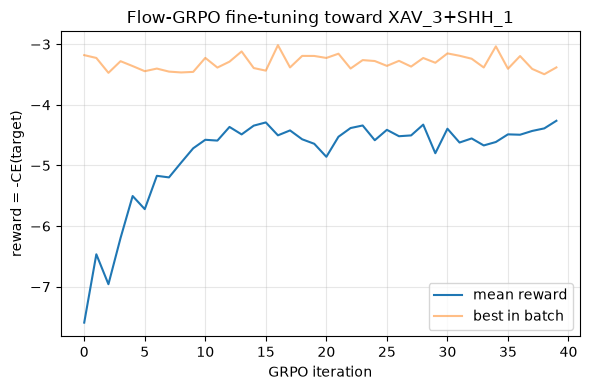

In [10]:
it  = [h["iter"] for h in history]
plt.figure(figsize=(6,4))
plt.plot(it, [h["reward"] for h in history], label="mean reward")
plt.plot(it, [h["reward_max"] for h in history], alpha=.5, label="best in batch")
plt.xlabel("GRPO iteration"); plt.ylabel("reward = -CE(target)")
plt.title(f"Flow-GRPO fine-tuning toward {TARGET_COMB}")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. After RL: sample new designs from the fine-tuned prior

In [11]:
# prior_flow was updated IN PLACE (policy shares its velocity_field)
designs_after = sample_prior(2000)
reward_after  = reward_model(torch.from_numpy(designs_after).float().to(DEVICE))
probs_after   = region_probs_for_designs(designs_after)
print(f"mean reward  before = {reward_before.mean().item():.4f}  ->  after = {reward_after.mean().item():.4f}")

mean reward  before = -7.5864  ->  after = -4.2494


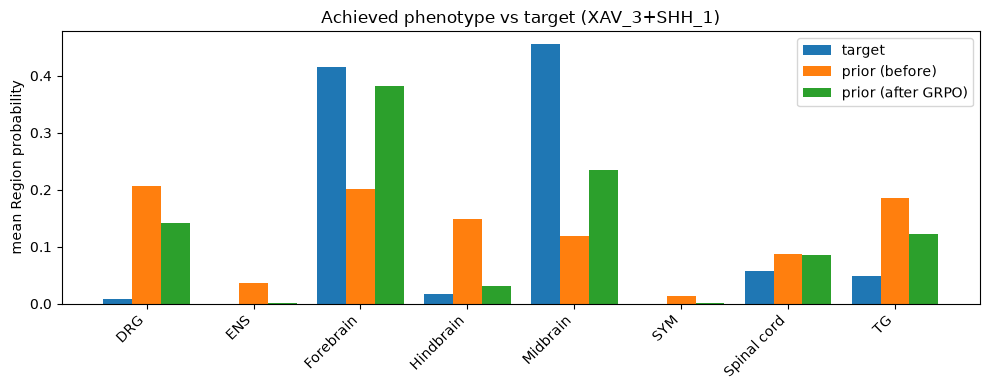

In [12]:
# phenotype match: target vs prior-before vs prior-after
x = np.arange(len(regions)); w = 0.27
plt.figure(figsize=(10,4))
plt.bar(x - w, target.ravel(), width=w, label="target")
plt.bar(x,      probs_before,  width=w, label="prior (before)")
plt.bar(x + w,  probs_after,   width=w, label="prior (after GRPO)")
plt.xticks(x, regions, rotation=45, ha="right")
plt.ylabel("mean Region probability"); plt.title(f"Achieved phenotype vs target ({TARGET_COMB})")
plt.legend(); plt.tight_layout(); plt.show()

In [13]:
# fine-tuned design distribution, per design dimension
# NOTE: the 6 design dims are the condition representation fed to the surrogate; their exact
# mapping to the named molecules is NOT the `molecules` tuple order (verify before naming dims).
dim_cols = [f"dim_{i}" for i in range(D)]
df_after = pd.DataFrame(designs_after, columns=dim_cols)
print("Fine-tuned design distribution (mean +/- std per dimension):")
print(pd.DataFrame({"mean": df_after.mean(), "std": df_after.std()}).round(3).to_string())
df_after.head()

Fine-tuned design distribution (mean +/- std per dimension):
        mean    std
dim_0  0.059  0.222
dim_1  0.721  0.612
dim_2  1.103  1.760
dim_3  0.320  0.918
dim_4  2.182  2.010
dim_5  0.137  0.309


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5
0,0.033177,1.215176,3.916696,0.000000,0.005488,0.026176
1,0.000000,1.312909,0.131704,3.143367,2.729252,0.074840
2,0.007697,1.371023,0.022097,0.000000,2.723970,0.019704
3,0.038701,0.963466,0.022525,0.039134,2.248284,0.012304
4,0.045933,1.531246,3.553791,0.000000,2.671320,0.029659


## 7. Save the fine-tuned prior

The prior was updated **in place** (the policy shares its `velocity_field`). Persist it so it can be
reloaded later with `FlowMatching.load(...)`. Re-saving under this Python also bakes in the
rebuilt pooling lambda, so the saved copy no longer needs `patch_pickled_lambdas`.

In [14]:
import os
SAVE_DIR = "/ictstr01/groups/ml01/workspace/ken_wang/LabCompass-RL/grpo_finetuned_prior"
os.makedirs(SAVE_DIR, exist_ok=True)
prior_flow.save(SAVE_DIR, model_prefix="grpo", overwrite=True)
print("saved ->", os.path.join(SAVE_DIR, "grpo_FlowMatching.pkl"))
# reload check:  prior_reloaded = FlowMatching.load(os.path.join(SAVE_DIR, "grpo_FlowMatching.pkl"))

saved -> /ictstr01/groups/ml01/workspace/ken_wang/LabCompass-RL/grpo_finetuned_prior/grpo_FlowMatching.pkl


## 8. Evaluate closeness to the ground-truth design

The **ground-truth design** for the target is the stored condition vector
`validation_adata.uns["conditions"][TARGET_COMB]` (call it `e*`). We measure how far the designs
sampled from the prior are from `e*`, **before vs after** fine-tuning.

> Caveat: `XAV_3+SHH_1` is flagged as *bimodal / non-identifiable* in the original notebook — several
> distinct protocols can induce the same phenotype. So matching the phenotype does **not** guarantee
> converging to this exact `e*`; we therefore also report the nearest ground-truth condition to the
> fine-tuned design distribution.

In [15]:
estar = np.maximum(np.asarray(validation_adata.uns["conditions"][TARGET_COMB]).ravel(), 0)  # [D]

def design_dist_stats(designs, ref):
    d = np.linalg.norm(designs - ref[None], axis=1)
    return dict(mean=float(d.mean()), median=float(np.median(d)), min=float(d.min()),
                mean_design_to_ref=float(np.linalg.norm(designs.mean(0) - ref)))

sb = design_dist_stats(designs_before, estar)
sa = design_dist_stats(designs_after,  estar)
print(f"L2(design -> e*)      mean : before {sb['mean']:.3f}  ->  after {sa['mean']:.3f}")
print(f"L2(design -> e*)      min  : before {sb['min']:.3f}  ->  after {sa['min']:.3f}   (best single design)")
print(f"L2(mean design -> e*)      : before {sb['mean_design_to_ref']:.3f}  ->  after {sa['mean_design_to_ref']:.3f}")

# nearest ground-truth condition to the fine-tuned mean design (non-identifiability check)
cond_names = list(validation_adata.uns["conditions"].keys())
cond_mat = np.stack([np.maximum(np.asarray(validation_adata.uns["conditions"][c]).ravel(), 0) for c in cond_names])
mean_after = designs_after.mean(0)
dall = np.linalg.norm(cond_mat - mean_after[None], axis=1)
ni = int(dall.argmin())
print(f"\nnearest ground-truth condition to fine-tuned mean design: {cond_names[ni]} (L2 {dall[ni]:.3f})")
print(f"target {TARGET_COMB} is at L2 {dall[cond_names.index(TARGET_COMB)]:.3f} "
      f"(rank {int((dall <= dall[cond_names.index(TARGET_COMB)]).sum())}/{len(cond_names)})")

L2(design -> e*)      mean : before 4.731  ->  after 3.437
L2(design -> e*)      min  : before 0.162  ->  after 0.249   (best single design)
L2(mean design -> e*)      : before 3.045  ->  after 2.220

nearest ground-truth condition to fine-tuned mean design: CHIR_2+SHH_1 (L2 1.314)
target XAV_3+SHH_1 is at L2 2.220 (rank 19/192)


### 8b. Evaluate against the *set* of phenotype-equivalent conditions

`XAV_3+SHH_1` is non-identifiable, so instead of the single design `e*` we build the **set** of
real conditions whose empirical Region phenotype is closest to the target (top-K by Jensen-Shannon
distance) and measure how close the sampled designs land to *any* member of that set.

In [16]:
def js_dist(p, q, eps=1e-12):
    p = np.clip(p, eps, 1); q = np.clip(q, eps, 1); m = 0.5*(p+q)
    kl = lambda a,b: np.sum(a*np.log(a/b), axis=-1)
    return np.sqrt(0.5*kl(p,m) + 0.5*kl(q,m))

# empirical phenotype (Region proportions from REAL cells) for every condition
obs_cond = validation_adata.obs["condition"].values
obs_reg  = validation_adata.obs["Region"].values
cond_names = list(validation_adata.uns["conditions"].keys())
cond2pheno, cond2design = {}, {}
for c in cond_names:
    m = obs_cond == c
    if m.sum() == 0: continue
    cond2pheno[c]  = ohe_region.transform(obs_reg[m].reshape(-1,1)).mean(0)
    cond2design[c] = np.maximum(np.asarray(validation_adata.uns["conditions"][c]).ravel(), 0)
target_pheno = cond2pheno[TARGET_COMB]

jsd = {c: float(js_dist(cond2pheno[c], target_pheno)) for c in cond2pheno}
order = sorted(jsd, key=jsd.get)
print("top phenotype-nearest conditions (JS distance to target):")
for c in order[:8]:
    print(f"   {jsd[c]:.4f}  {c}")

TOPK = 10
equiv_set  = order[:TOPK]
design_set = np.stack([cond2design[c] for c in equiv_set])

top phenotype-nearest conditions (JS distance to target):
   0.0000  XAV_3+SHH_1
   0.1581  XAV_3
   0.1598  CHIR_1+SHH_2
   0.1786  CHIR_1+SHH_1
   0.1832  FGF8_1
   0.1843  XAV_1+SHH_1
   0.1863  XAV_2
   0.1867  CHIR_1


In [17]:
from scipy.spatial.distance import cdist
nb_set = cdist(designs_before, design_set).min(1)   # nearest phenotype-equiv protocol per design
na_set = cdist(designs_after,  design_set).min(1)
sb_arr = np.linalg.norm(designs_before - estar[None], axis=1)
sa_arr = np.linalg.norm(designs_after  - estar[None], axis=1)
def summ(x): return f"mean={x.mean():.3f} median={np.median(x):.3f} min={x.min():.3f}"
print(f"L2 to SINGLE e*             before: {summ(sb_arr)}")
print(f"L2 to SINGLE e*             after : {summ(sa_arr)}")
print(f"L2 to phenotype-equiv SET   before: {summ(nb_set)}")
print(f"L2 to phenotype-equiv SET   after : {summ(na_set)}")

# is the RL basin actually phenotype-equivalent (by real-cell phenotype)?
mean_after = designs_after.mean(0)
valid = list(cond2design.keys())
dall = np.linalg.norm(np.stack([cond2design[c] for c in valid]) - mean_after[None], axis=1)
nc = valid[int(dall.argmin())]
print(f"\nnearest condition to fine-tuned mean design: {nc} "
      f"(design L2 {dall.min():.3f}, phenotype JS {jsd[nc]:.4f}, in top-{TOPK} set: {nc in equiv_set})")

L2 to SINGLE e*             before: mean=4.731 median=4.643 min=0.162
L2 to SINGLE e*             after : mean=3.437 median=3.281 min=0.249
L2 to phenotype-equiv SET   before: mean=3.096 median=3.098 min=0.031
L2 to phenotype-equiv SET   after : mean=1.565 median=1.192 min=0.049

nearest condition to fine-tuned mean design: CHIR_2+SHH_1 (design L2 1.314, phenotype JS 0.2180, in top-10 set: False)


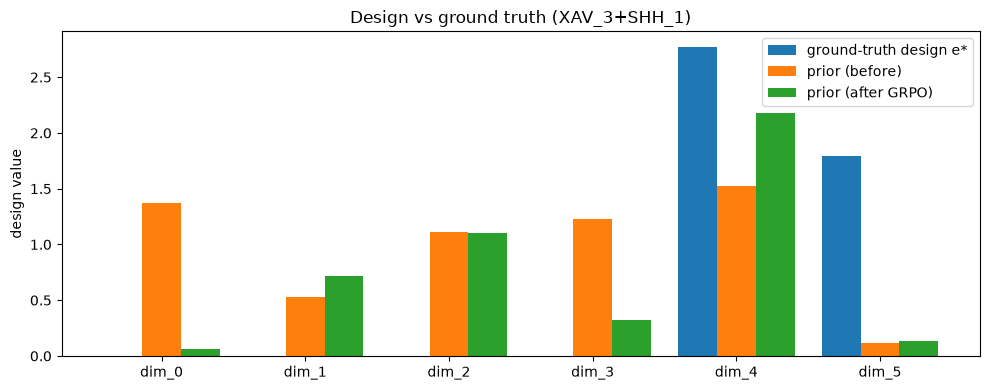

In [18]:
# per-dimension comparison: ground-truth design vs prior before/after
xm = np.arange(D); w = 0.27
plt.figure(figsize=(10,4))
plt.bar(xm - w, estar,                 width=w, label="ground-truth design e*")
plt.bar(xm,      designs_before.mean(0), width=w, label="prior (before)")
plt.bar(xm + w,  designs_after.mean(0),  width=w, label="prior (after GRPO)")
plt.xticks(xm, [f"dim_{i}" for i in range(D)])
plt.ylabel("design value"); plt.title(f"Design vs ground truth ({TARGET_COMB})")
plt.legend(); plt.tight_layout(); plt.show()

### 8c. Optimal condition — the correct predictive routine

The metrics above are **distribution-level** (whole-batch mean). To read off the model's predicted
**optimal design condition**, rank the sampled designs by reward and summarize the *best* ones — not
the mean of the whole batch. Note that the single argmax is a **noisy** pick (the reward is a
finite-cell estimate), so the trustworthy optimum is the **centroid of the top-1%** (or the modal
nearest real protocol among the top designs), then validated by its predicted phenotype.

In [19]:
from collections import Counter
rew = reward_after.detach().cpu().numpy()          # per-design reward (already computed)
order = np.argsort(-rew)                            # best first

# (A) single best design (argmax) -- UNRELIABLE: reward is a finite-cell estimate
best = int(order[0]); d_best = designs_after[best]
probs_best = region_probs_for_designs(d_best[None], n_forward=1000)
ib = int(np.linalg.norm(cond_mat - d_best[None], axis=1).argmin())
print(f"[argmax]      reward {rew[best]:.3f} | nearest {cond_names[ib]:18s} "
      f"(phenoJS {jsd.get(cond_names[ib], float('nan')):.3f}) | predicted-phenotype JS {js_dist(probs_best, target_pheno):.3f}")

# (B) ROBUST optimum: centroid of the top-1% highest-reward designs
topk = order[:max(1, len(order)//100)]
d_top = designs_after[topk].mean(0)
probs_top = region_probs_for_designs(d_top[None], n_forward=1000)
it = int(np.linalg.norm(cond_mat - d_top[None], axis=1).argmin())
print(f"[top-1% mean] design {np.round(d_top,3)}")
print(f"              nearest {cond_names[it]:18s} (phenoJS {jsd.get(cond_names[it], float('nan')):.3f}) "
      f"| predicted-phenotype JS {js_dist(probs_top, target_pheno):.3f}")

# (C) modal optimum: most frequent nearest real condition among the top-50 designs
near = [cond_names[int(np.linalg.norm(cond_mat - designs_after[k][None], axis=1).argmin())] for k in order[:50]]
print(f"[mode top-50] {Counter(near).most_common(5)}")

print(f"\n==> OPTIMAL CONDITION (robust): {cond_names[it]}  "
      f"(target is {TARGET_COMB}; phenoJS of chosen = {jsd.get(cond_names[it], float('nan')):.3f})")

[argmax]      reward -3.128 | nearest CHIR_4+SHH_1       (phenoJS 0.376) | predicted-phenotype JS 0.301
[top-1% mean] design [0.015 1.198 0.361 0.699 2.61  0.351]
              nearest RA_1+CHIR_4+SHH_1  (phenoJS 0.374) | predicted-phenotype JS 0.276
[mode top-50] [('CHIR_4', 8), ('RA_1+CHIR_4+SHH_2', 7), ('RA_1+CHIR_4', 6), ('XAV_3+SHH_2', 4), ('CHIR_4+SHH_1', 3)]

==> OPTIMAL CONDITION (robust): RA_1+CHIR_4+SHH_1  (target is XAV_3+SHH_1; phenoJS of chosen = 0.374)


## 9. Scaling up (bigger run)

The run above is a fast demo. Set `RUN_BIG = True` to launch a larger, stronger fine-tuning run
(minutes on an H100). The reward call is the main cost: it simulates
`batch_size x num_forward_pass_per_sample` cells through the surrogate per iteration.

In [20]:
RUN_BIG = False   # set True to run the larger configuration

if RUN_BIG:
    # (optional) start fresh so the demo run above does not compound
    # prior_flow = FlowMatching.load(PRIOR_FLOW_MODEL_PATH); patch_pickled_lambdas(prior_flow)
    # policy = FlowPolicy(prior_flow).to(DEVICE)
    reward_model_big = RewardModel(
        forward_model, loss_fns, {"Region": target},
        num_forward_pass_per_sample=128, n_time_steps_forward_model=20,
        non_linearity=torch.nn.ReLU(),
    ).to(DEVICE)

    cfg_big = FlowGRPOConfig()
    cfg_big.batch_size   = 256
    cfg_big.T            = 10
    cfg_big.inner_epochs = 4
    cfg_big.noise_level  = 0.7
    cfg_big.kl_coef      = 0.3     # recommended operating point (see kl sweep / Pareto)
    cfg_big.lr           = 3e-4
    cfg_big.total_iters  = 250

    history_big = train_flow_grpo(policy, reward_model_big, data_shape=(D,),
                                  cfg=cfg_big, device=DEVICE, log_every=10)
    prior_flow.save(SAVE_DIR, model_prefix="grpo_big", overwrite=True)
    print("saved big-run prior ->", os.path.join(SAVE_DIR, "grpo_big_FlowMatching.pkl"))
else:
    print("RUN_BIG is False - skipping the large run.")

RUN_BIG is False - skipping the large run.


## Notes / scaling up

* **This is a demo config.** For stronger steering increase `cfg.total_iters` (e.g. 200–400),
  `cfg.batch_size`, and `RewardModel(num_forward_pass_per_sample=...)` (more cells per design →
  lower-variance reward). The reward call is the main cost (surrogate ODE over
  `batch_size × num_forward_pass` cells per iteration).
* **`cfg.kl_coef`** keeps the fine-tuned prior close to the original design manifold; lower it for
  more aggressive optimization, raise it if designs drift to implausible / surrogate-exploiting regions.
* **Reward** here is `-cross_entropy` to the target Region distribution. Swap `loss_fns` / `target`
  in `RewardModel` to optimize a different phenotype, add multiple covariates, or add a design-space
  regularizer.
* The fine-tuned prior lives in `prior_flow` (updated in place). Persist it with
  `prior_flow.save(<dir>)` and reload with `FlowMatching.load(...)`.